# mmraz-time-utility-experiment-vast

Goal: measure **Qwen 3 4B** time preference behavior on prompts of the form:

`What would you prefer {x}$ now or {y}$ in {t}? Answer in just a few words.`

Experiment setup:
- `x = 100` fixed.
- `y` in `[100, 101, 110, 150, 200, 500, 1000, 10000]`.
- `t` in `[tomorrow, week, month, year, 2 years, 3 years, 5 years, 10 years]`.
- Run each `(x, y, t)` pair exactly **1 time** with deterministic decoding (`do_sample=False`).
- Default model is `Qwen/Qwen3-4B` for the Vast.ai run.

Runtime toggle:
- Set `ENABLE_THINKING = False` to keep the previous no-thinking chat-template behavior.
- Set `ENABLE_THINKING = True` to allow thinking traces, strip them before parsing the final choice, and save outputs under distinct `with_thinking` artifact names.

Outputs:
- Parsed choice outcomes (`x_now`, `y_later`, `unparsed`).
- Raw model completions are always stored in the artifacts under `response`.
- When thinking is enabled, parsing uses `response_for_parse`, which removes the `<think>...</think>` block before scoring the final answer.
- Baseline raw/summary CSVs, config JSON, `choose x now` heatmap PNG, and `unparsed rate` heatmap PNG.
- Steered raw/summary CSVs, config JSON, and per-condition `choose x now` / `unparsed rate` heatmap PNGs.


In [ ]:
from pathlib import Path
import re
import time
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoModelForCausalLM, AutoTokenizer


/opt/conda/envs/venv_remote_3112/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / 'pyproject.toml').exists() and (p / 'notebooks').exists():
            return p
        p = p.parent
    raise RuntimeError('Could not locate repo root from current working directory.')

ROOT = find_repo_root(Path.cwd())
print('Repo root:', ROOT)

# Vast-targeted configuration: run the Qwen 3 4B checkpoint on CUDA when available.
MODEL_NAME = 'Qwen/Qwen3-4B'
USE_CHAT_TEMPLATE = True
ENABLE_THINKING = bool(globals().get('ENABLE_THINKING', False))
DISABLE_THINKING_TRACE = not ENABLE_THINKING
THINKING_MODE_TAG = 'with_thinking' if ENABLE_THINKING else 'without_thinking'
MAX_NEW_TOKENS = 2048 if ENABLE_THINKING else 128

print('Thinking enabled:', ENABLE_THINKING)
print('Artifact mode tag:', THINKING_MODE_TAG)

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)
if device != 'cuda':
    print('Note: Vast.ai runs are expected to use a CUDA GPU; this notebook is falling back to', device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model_load_kwargs = {'trust_remote_code': True}
if device == 'cuda':
    model_load_kwargs['dtype'] = torch.float16
elif device == 'mps':
    model_load_kwargs['dtype'] = torch.float16
else:
    model_load_kwargs['dtype'] = torch.float32

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **model_load_kwargs)

model = model.to(device)

model.eval()

x_now = 100
y_values = [100, 101, 110, 150, 200, 500, 1000, 10000]
t_values = ['tomorrow', 'week', 'month', 'year', '2 years', '3 years', '5 years', '10 years']
n_repeats = 1

generation_kwargs = {
    'max_new_tokens': MAX_NEW_TOKENS,
    'do_sample': False,
    'pad_token_id': tokenizer.eos_token_id,
    'eos_token_id': tokenizer.eos_token_id,
}

primary_model_device = next(model.parameters()).device
print(f'Model loaded: {MODEL_NAME}')
print('Primary model device:', primary_model_device)
print('Deterministic decoding config:', generation_kwargs)
print('Max new tokens:', MAX_NEW_TOKENS)
print(f'Grid size: {len(y_values)} y-values x {len(t_values)} t-values x {n_repeats} repeat = {len(y_values) * len(t_values) * n_repeats} generations')


Repo root: /workspace
Device: cuda


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 579/579 [00:02<00:00, 220.94it/s]


Model loaded: Qwen/Qwen2.5-14B-Instruct
Primary model device: cpu
Deterministic decoding config: {'max_new_tokens': 16, 'do_sample': False, 'pad_token_id': 151645, 'eos_token_id': 151645}
Grid size: 8 y-values x 8 t-values x 1 repeat = 64 generations


In [ ]:
THINKING_BLOCK_RE = re.compile(r'<think>.*?</think>', flags=re.IGNORECASE | re.DOTALL)


def build_prompt(x: int, y: int, t: str) -> str:
    return f'What would you prefer {x}$ now or {y}$ in {t}? Answer in just a few words.'


def format_for_model(user_prompt: str) -> str:
    if USE_CHAT_TEMPLATE and hasattr(tokenizer, 'apply_chat_template'):
        messages = [{'role': 'user', 'content': user_prompt}]
        try:
            return tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
                enable_thinking=ENABLE_THINKING,
            )
        except TypeError:
            templated = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            if DISABLE_THINKING_TRACE:
                return templated + '<think>\n</think>\n\n'
            return templated
    return user_prompt


def strip_thinking_trace_for_parse(response: str) -> str:
    text = (response or '').strip()
    if not text or not ENABLE_THINKING:
        return text

    cleaned = THINKING_BLOCK_RE.sub(' ', text)
    cleaned = re.sub(r'\n{3,}', '\n\n', cleaned).strip()
    if cleaned:
        return cleaned

    close_match = re.search(r'</think\s*>', text, flags=re.IGNORECASE)
    if close_match is not None:
        trailing = text[close_match.end():].strip()
        if trailing:
            return trailing

    return text


def prepare_response_for_parse(response: str) -> str:
    return strip_thinking_trace_for_parse(response).strip()


def get_input_device() -> torch.device:
    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device(device)


def move_batch_to_model_device(batch):
    input_device = get_input_device()
    return {k: v.to(input_device) for k, v in batch.items()}


def generate_response(prompt: str) -> str:
    model_input_text = format_for_model(prompt)
    enc = tokenizer(model_input_text, return_tensors='pt')
    enc = move_batch_to_model_device(enc)
    with torch.inference_mode():
        out = model.generate(**enc, **generation_kwargs)
    new_ids = out[0, enc['input_ids'].shape[1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=True).strip()


def parse_choice(response: str, x: int, y: int, t: str) -> str:
    # Returns one of: 'x_now', 'y_later', 'unparsed'.
    text = prepare_response_for_parse(response)
    if not text:
        return 'unparsed'

    lower = text.lower()
    t_lower = t.lower()
    now_score = 0
    later_score = 0

    if y != x:
        if re.search(rf"\b{x}\s*\$?\b", lower):
            now_score += 1
        if re.search(rf"\b{y}\s*\$?\b", lower):
            later_score += 1

    if re.search(r"\b(now|today|immediately|right now|upfront|up front)\b", lower):
        now_score += 1
    if re.search(r"\b(later|wait|waiting|future|after|eventually|defer|delayed)\b", lower):
        later_score += 1
    if t_lower in lower:
        later_score += 1

    if re.search(rf"\b(prefer|choose|take|pick|go with|would take|i(?:'d| would) take|i(?:'d| would) choose)\b[^.!?\n]{{0,60}}\b({x}|now|today|immediately)\b", lower):
        now_score += 2
    if re.search(rf"\b(prefer|choose|take|pick|go with|would take|i(?:'d| would) take|i(?:'d| would) choose)\b[^.!?\n]{{0,80}}\b({y}|later|wait|{re.escape(t_lower)})\b", lower):
        later_score += 2

    if re.search(r"\b(worth|better)\s+to\s+wait\b", lower):
        later_score += 1
    if re.search(r"\b(can(?:not|'t)|do\s+not|don't|won't|wouldn't)\s+wait\b", lower):
        now_score += 1

    if now_score > later_score:
        return 'x_now'
    if later_score > now_score:
        return 'y_later'

    now_markers = [
        lower.find(' now'),
        lower.find('today'),
        lower.find('immediately'),
        lower.find('right now'),
    ]
    later_markers = [
        lower.find('later'),
        lower.find('wait'),
        lower.find('future'),
        lower.find(t_lower),
    ]

    now_pos = min([p for p in now_markers if p >= 0], default=-1)
    later_pos = min([p for p in later_markers if p >= 0], default=-1)

    if now_pos >= 0 and (later_pos < 0 or now_pos < later_pos):
        return 'x_now'
    if later_pos >= 0 and (now_pos < 0 or later_pos < now_pos):
        return 'y_later'

    return 'unparsed'


In [ ]:
records = []
total = len(y_values) * len(t_values)
counter = 0
start_time = time.time()

for y in y_values:
    for t in t_values:
        prompt = build_prompt(x_now, y, t)
        response = generate_response(prompt)
        response_for_parse = prepare_response_for_parse(response)
        parsed_choice = parse_choice(response, x_now, y, t)

        counter += 1
        records.append({
            'x_now': x_now,
            'y_later': y,
            't_delay': t,
            'repeat_idx': 1,
            'prompt': prompt,
            'response': response,
            'response_for_parse': response_for_parse,
            'thinking_trace_removed_for_parse': bool(ENABLE_THINKING and response_for_parse != (response or '').strip()),
            'choice': parsed_choice,
        })

        if counter % 10 == 0 or counter == total:
            elapsed = time.time() - start_time
            print(f'Progress: {counter}/{total} ({100.0 * counter / total:.1f}%) | elapsed {elapsed / 60.0:.1f} min')

results_df = pd.DataFrame(records)
display(results_df.head(20))

print('Choice counts:')
print(results_df['choice'].value_counts(dropna=False))


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Progress: 10/64 (15.6%) | elapsed 1.7 min
Progress: 20/64 (31.2%) | elapsed 3.5 min
Progress: 30/64 (46.9%) | elapsed 5.3 min
Progress: 40/64 (62.5%) | elapsed 7.4 min
Progress: 50/64 (78.1%) | elapsed 9.3 min
Progress: 60/64 (93.8%) | elapsed 11.5 min
Progress: 64/64 (100.0%) | elapsed 12.5 min


,x_now,y_later,t_delay,repeat_idx,prompt,response,choice
0,100,100,tomorrow,1,What would you prefer 100$ now or 100$ in tomo...,100$ now,x_now
1,100,100,week,1,What would you prefer 100$ now or 100$ in week...,100$ now,x_now
2,100,100,month,1,What would you prefer 100$ now or 100$ in mont...,100$ now,x_now
3,100,100,year,1,What would you prefer 100$ now or 100$ in year...,100$ now,x_now
4,100,100,2 years,1,What would you prefer 100$ now or 100$ in 2 ye...,100$ now,x_now
5,100,100,3 years,1,What would you prefer 100$ now or 100$ in 3 ye...,100$ now,x_now
6,100,100,5 years,1,What would you prefer 100$ now or 100$ in 5 ye...,100$ now,x_now
7,100,100,10 years,1,What would you prefer 100$ now or 100$ in 10 y...,100$ now.,x_now
8,100,101,tomorrow,1,What would you prefer 100$ now or 101$ in tomo...,100$ now.,x_now
9,100,101,week,1,What would you prefer 100$ now or 101$ in week...,100$ now,x_now


Choice counts:
choice
x_now       42
y_later     20
unparsed     2
Name: count, dtype: int64


In [ ]:
results_df['choose_y_binary'] = results_df['choice'].map({'x_now': 0.0, 'y_later': 1.0})

summary_df = (
    results_df
    .groupby(['y_later', 't_delay'], as_index=False)
    .agg(
        n_total=('choice', 'size'),
        n_choose_x=('choice', lambda x: int((x == 'x_now').sum())),
        n_choose_y=('choice', lambda x: int((x == 'y_later').sum())),
        n_unparsed=('choice', lambda x: int((x == 'unparsed').sum())),
    )
)

summary_df['n_parsed'] = summary_df['n_choose_x'] + summary_df['n_choose_y']
summary_df['prop_choose_x_parsed'] = np.where(
    summary_df['n_parsed'] > 0,
    summary_df['n_choose_x'] / summary_df['n_parsed'],
    np.nan,
)
summary_df['prop_choose_y_parsed'] = np.where(
    summary_df['n_parsed'] > 0,
    summary_df['n_choose_y'] / summary_df['n_parsed'],
    np.nan,
)
summary_df['unparsed_rate'] = summary_df['n_unparsed'] / summary_df['n_total']

summary_df = summary_df.sort_values(['y_later', 't_delay']).reset_index(drop=True)
display(summary_df)

print('Overall parsed rate:', round(float((results_df['choice'] != 'unparsed').mean()), 4))
print('Overall unparsed rate:', round(float((results_df['choice'] == 'unparsed').mean()), 4))


,y_later,t_delay,n_total,n_choose_x,n_choose_y,n_unparsed,n_parsed,prop_choose_x_parsed,prop_choose_y_parsed,unparsed_rate
0,100,10 years,1,1,0,0,1,1.0,0.0,0.0
1,100,2 years,1,1,0,0,1,1.0,0.0,0.0
2,100,3 years,1,1,0,0,1,1.0,0.0,0.0
3,100,5 years,1,1,0,0,1,1.0,0.0,0.0
4,100,month,1,1,0,0,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
59,10000,5 years,1,0,1,0,1,0.0,1.0,0.0
60,10000,month,1,0,1,0,1,0.0,1.0,0.0
61,10000,tomorrow,1,0,1,0,1,0.0,1.0,0.0
62,10000,week,1,0,1,0,1,0.0,1.0,0.0


Overall parsed rate: 0.9688
Overall unparsed rate: 0.0312


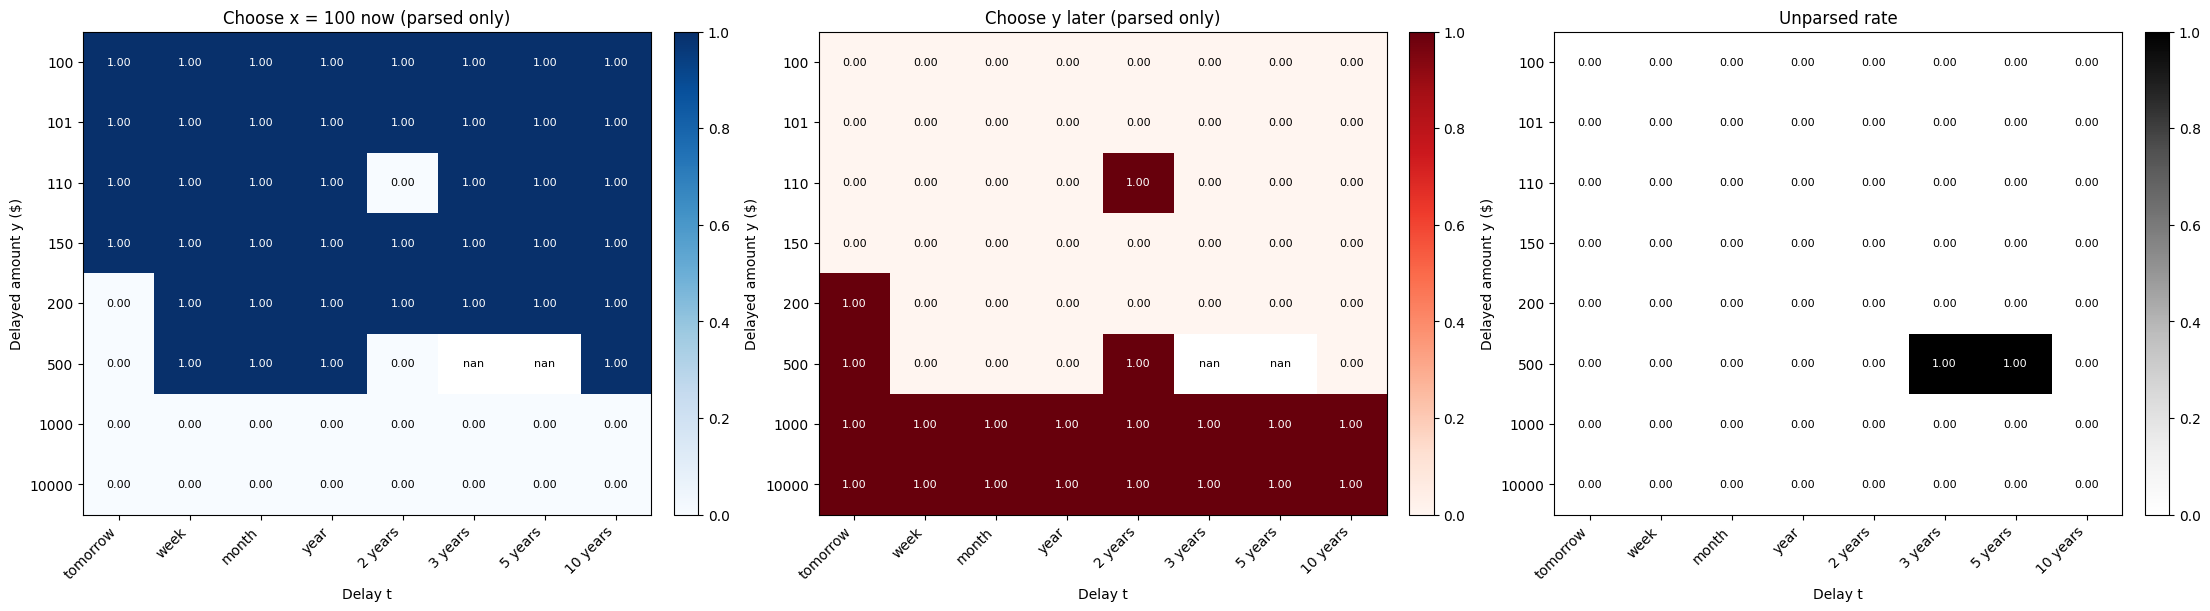

In [ ]:
def to_matrix(df: pd.DataFrame, value_col: str) -> np.ndarray:
    pivot = df.pivot(index='y_later', columns='t_delay', values=value_col)
    pivot = pivot.reindex(index=y_values, columns=t_values)
    return pivot.to_numpy(dtype=float)


def draw_heatmap(ax, matrix, title, vmin=0.0, vmax=1.0, cmap='viridis', fmt='{:.2f}'):
    im = ax.imshow(matrix, aspect='auto', origin='upper', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('Delay t')
    ax.set_ylabel('Delayed amount y ($)')
    ax.set_xticks(np.arange(len(t_values)))
    ax.set_xticklabels(t_values, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(y_values)))
    ax.set_yticklabels(y_values)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            label = 'nan' if np.isnan(val) else fmt.format(val)
            color = 'white' if (not np.isnan(val) and val > 0.55) else 'black'
            ax.text(j, i, label, ha='center', va='center', fontsize=8, color=color)

    return im

prop_x_matrix = to_matrix(summary_df, 'prop_choose_x_parsed')
unparsed_matrix = to_matrix(summary_df, 'unparsed_rate')

fig_x, ax_x = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
im_x = draw_heatmap(ax_x, prop_x_matrix, 'Choose x = 100 now (parsed only)', vmin=0.0, vmax=1.0, cmap='Blues')
fig_x.colorbar(im_x, ax=ax_x, fraction=0.046, pad=0.04)

fig_unparsed, ax_unparsed = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
im_unparsed = draw_heatmap(ax_unparsed, unparsed_matrix, 'Unparsed rate', vmin=0.0, vmax=1.0, cmap='Greys')
fig_unparsed.colorbar(im_unparsed, ax=ax_unparsed, fraction=0.046, pad=0.04)
baseline_output_dir = ROOT / 'results' / f'time_utility_experiment_qwen3_4b_vast_deterministic_{THINKING_MODE_TAG}'
baseline_output_dir.mkdir(parents=True, exist_ok=True)
baseline_choose_x_plot_path = baseline_output_dir / f'mmraz_time_utility_qwen3_4b_vast_{THINKING_MODE_TAG}_choose_x_now_heatmap.png'
baseline_unparsed_plot_path = baseline_output_dir / f'mmraz_time_utility_qwen3_4b_vast_{THINKING_MODE_TAG}_unparsed_rate_heatmap.png'
fig_x.savefig(baseline_choose_x_plot_path, dpi=200, bbox_inches='tight')
fig_unparsed.savefig(baseline_unparsed_plot_path, dpi=200, bbox_inches='tight')
display(fig_x)
display(fig_unparsed)
plt.close(fig_x)
plt.close(fig_unparsed)
print('Saved baseline choose-x heatmap   :', baseline_choose_x_plot_path)
print('Saved baseline unparsed heatmap  :', baseline_unparsed_plot_path)


In [ ]:
output_dir = ROOT / 'results' / f'time_utility_experiment_qwen3_4b_vast_deterministic_{THINKING_MODE_TAG}'
output_dir.mkdir(parents=True, exist_ok=True)

raw_path = output_dir / f'mmraz_time_utility_qwen3_4b_vast_{THINKING_MODE_TAG}_raw.csv'
summary_path = output_dir / f'mmraz_time_utility_qwen3_4b_vast_{THINKING_MODE_TAG}_summary.csv'
config_path = output_dir / f'mmraz_time_utility_qwen3_4b_vast_{THINKING_MODE_TAG}_config.json'

results_df.to_csv(raw_path, index=False)
summary_df.to_csv(summary_path, index=False)
config_payload = {
    'model_name': MODEL_NAME,
    'use_chat_template': bool(USE_CHAT_TEMPLATE),
    'enable_thinking': bool(ENABLE_THINKING),
    'disable_thinking_trace': bool(DISABLE_THINKING_TRACE),
    'thinking_mode_tag': THINKING_MODE_TAG,
    'device': str(primary_model_device),
    'prompt_format': 'direct_time_utility_question',
    'prompt_template': 'What would you prefer {x}$ now or {y}$ in {t}? Answer in just a few words.',
    'x_now': x_now,
    'y_values': y_values,
    't_values': t_values,
    'n_repeats': n_repeats,
    'generation_kwargs': generation_kwargs,
    'response_field_raw': 'response',
    'response_field_for_parse': 'response_for_parse',
    'choose_x_heatmap_path': str(baseline_choose_x_plot_path),
    'unparsed_heatmap_path': str(baseline_unparsed_plot_path),
}
config_path.write_text(json.dumps(config_payload, indent=2) + '\n')

print('Saved raw outputs   :', raw_path)
print('Saved summary table :', summary_path)
print('Saved baseline config:', config_path)


Saved raw outputs   : /workspace/results/time_utility_experiment_vast_deterministic/mmraz_time_utility_vast_raw.csv
Saved summary table : /workspace/results/time_utility_experiment_vast_deterministic/mmraz_time_utility_vast_summary.csv


In [ ]:
results_df

,x_now,y_later,t_delay,repeat_idx,prompt,response,choice,choose_y_binary
0,100,100,tomorrow,1,What would you prefer 100$ now or 100$ in tomo...,100$ now,x_now,0.0
1,100,100,week,1,What would you prefer 100$ now or 100$ in week...,100$ now,x_now,0.0
2,100,100,month,1,What would you prefer 100$ now or 100$ in mont...,100$ now,x_now,0.0
3,100,100,year,1,What would you prefer 100$ now or 100$ in year...,100$ now,x_now,0.0
4,100,100,2 years,1,What would you prefer 100$ now or 100$ in 2 ye...,100$ now,x_now,0.0
...,...,...,...,...,...,...,...,...
59,100,10000,year,1,What would you prefer 100$ now or 10000$ in ye...,10000$ in a year.,y_later,1.0
60,100,10000,2 years,1,What would you prefer 100$ now or 10000$ in 2 ...,10000$ in 2 years.,y_later,1.0
61,100,10000,3 years,1,What would you prefer 100$ now or 10000$ in 3 ...,10000$ in 3 years.,y_later,1.0
62,100,10000,5 years,1,What would you prefer 100$ now or 10000$ in 5 ...,10000$ in 5 years.,y_later,1.0


In [ ]:
response_preview_col = 'response_for_parse' if 'response_for_parse' in results_df.columns else 'response'
print('Preview response column:', response_preview_col)
for y in results_df.y_later.unique():
    for t in results_df.t_delay.unique():
        print(f'y={y}, t={t}: {results_df.loc[(results_df.y_later == y) & (results_df.t_delay == t), response_preview_col].iloc[0]}')


y=100, t=tomorrow: 100$ now
y=100, t=week: 100$ now
y=100, t=month: 100$ now
y=100, t=year: 100$ now
y=100, t=2 years: 100$ now
y=100, t=3 years: 100$ now
y=100, t=5 years: 100$ now
y=100, t=10 years: 100$ now.
y=101, t=tomorrow: 100$ now.
y=101, t=week: 100$ now
y=101, t=month: 100$ now
y=101, t=year: 100$ now
y=101, t=2 years: 100$ now
y=101, t=3 years: 100$ now
y=101, t=5 years: 100$ now
y=101, t=10 years: 100$ now.
y=110, t=tomorrow: 100$ now.
y=110, t=week: 100$ now
y=110, t=month: 100$ now
y=110, t=year: 100$ now
y=110, t=2 years: 110$ in 2 years, assuming no better investment options.
y=110, t=3 years: 100$ now
y=110, t=5 years: 100$ now
y=110, t=10 years: 100$ now
y=150, t=tomorrow: 100$ now.
y=150, t=week: 100$ now
y=150, t=month: 100$ now
y=150, t=year: 100$ now
y=150, t=2 years: 100$ now
y=150, t=3 years: 100$ now
y=150, t=5 years: 100$ now
y=150, t=10 years: 100$ now.
y=200, t=tomorrow: 200$ tomorrow
y=200, t=week: 100$ now
y=200, t=month: 100$ now
y=200, t=year: 100$ now
y

## Layer-22 MM Steering Sweep

This section loads the **Qwen/Qwen3-4B** probe bundle from the Vast `mmraz-qwen-probe-variations-question-options-answer-vast` run, selects the **explicit-train-only / mean-answer-tokens / layer-22 MM steering vector**, and reruns the time-utility grid under a single signed-strength sweep:

- `steer_long_term_plus16`
- `steer_immediate_minus16`
- `steer_long_term_plus32`
- `steer_immediate_minus32`
- `steer_long_term_plus64`
- `steer_immediate_minus64`

It saves a fresh steered results bundle under a mode-specific `results/time_utility_experiment_qwen3_4b_vast_deterministic_steered_probe_variations_*` directory so thinking and no-thinking runs do not overwrite each other.


In [ ]:
import json

REQUIRED_QWEN_PROBE_ARTIFACT_FORMAT_VERSION = 4

STEERING_ARTIFACT_PATH = globals().get('STEERING_ARTIFACT_PATH', None)
STEERING_METADATA_PATH = globals().get('STEERING_METADATA_PATH', None)
STEERING_LAYER = int(globals().get('STEERING_LAYER', 22))
STEERING_VECTOR_KEY = globals().get('STEERING_VECTOR_KEY', 'mm_steering_vectors')
STEERING_TRAIN_REGIME = globals().get('STEERING_TRAIN_REGIME', None)
STEERING_FEATURE_NAME = globals().get('STEERING_FEATURE_NAME', None)
STEERING_STRENGTHS = [16.0, 32.0, 64.0]
STEERING_CONDITIONS = []
for strength in STEERING_STRENGTHS:
    strength_tag = int(abs(strength)) if float(abs(strength)).is_integer() else str(abs(strength)).replace('.', 'p')
    STEERING_CONDITIONS.extend([
        {'condition': f'steer_long_term_plus{strength_tag}', 'signed_strength': float(strength)},
        {'condition': f'steer_immediate_minus{strength_tag}', 'signed_strength': float(-strength)},
    ])
STEERING_SEARCH_ROOTS = [
    ROOT / 'results' / 'qwen_question_options_answer_probe_variations_vast',
    ROOT / 'results',
    Path('/workspace/results'),
    Path('/workspace'),
]


def _unique_paths(paths):
    seen = set()
    unique = []
    for path in paths:
        resolved = path.resolve()
        if resolved not in seen:
            unique.append(path)
            seen.add(resolved)
    return unique


def _decode_str_array(values):
    decoded = []
    for value in values:
        if isinstance(value, bytes):
            decoded.append(value.decode('utf-8'))
        else:
            decoded.append(str(value))
    return decoded


def _resolve_metadata_path_for_artifact(artifact_path, metadata_candidates):
    candidate = artifact_path.with_name(artifact_path.name.replace('_probe_artifacts_', '_probe_metadata_').replace('.npz', '.json'))
    if candidate.exists():
        return candidate
    for metadata_path in metadata_candidates:
        if metadata_path.stem.replace('_probe_metadata_', '_probe_artifacts_') == artifact_path.stem:
            return metadata_path
    return None


def _load_probe_metadata(metadata_path):
    if metadata_path is None or not metadata_path.exists():
        return None
    return json.loads(metadata_path.read_text())


def _metadata_is_compatible(metadata):
    if not metadata:
        return False
    if int(metadata.get('artifact_format_version', 0)) < REQUIRED_QWEN_PROBE_ARTIFACT_FORMAT_VERSION:
        return False
    if metadata.get('explicit_split_granularity') != 'pair':
        return False
    if not bool(metadata.get('probe_prompt_use_chat_template', metadata.get('use_chat_template', False))):
        return False
    if not bool(metadata.get('probe_prompt_disable_thinking_trace', metadata.get('disable_thinking_trace', False))):
        return False
    return True


def find_latest_qwen_probe_artifacts(search_roots):
    artifact_candidates = []
    metadata_candidates = []
    for root in search_roots:
        if not root.exists():
            continue
        artifact_candidates.extend(sorted(root.rglob('qwen3_4b_question_options_answer_probe_artifacts_*.npz')))
        metadata_candidates.extend(sorted(root.rglob('qwen3_4b_question_options_answer_probe_metadata_*.json')))

    artifact_candidates = _unique_paths(artifact_candidates)
    metadata_candidates = _unique_paths(metadata_candidates)

    if not artifact_candidates:
        search_roots_str = ', '.join(str(root) for root in search_roots)
        raise FileNotFoundError(
            'Could not find any Qwen probe-variation artifacts under: '
            f'{search_roots_str}. If needed, set STEERING_ARTIFACT_PATH explicitly to the exact .npz path.'
        )

    compatible_candidates = []
    for artifact_path in reversed(artifact_candidates):
        metadata_path = _resolve_metadata_path_for_artifact(artifact_path, metadata_candidates)
        metadata = _load_probe_metadata(metadata_path)
        if _metadata_is_compatible(metadata):
            compatible_candidates.append((artifact_path, metadata_path))

    if not compatible_candidates:
        search_roots_str = ', '.join(str(root) for root in search_roots)
        raise FileNotFoundError(
            'Found Qwen probe-variation artifacts, but none matched the required pair-level + chat-template artifact format '
            f'(artifact_format_version >= {REQUIRED_QWEN_PROBE_ARTIFACT_FORMAT_VERSION}). Search roots: {search_roots_str}'
        )

    return compatible_candidates[0]


if STEERING_ARTIFACT_PATH is None:
    steering_artifact_path, steering_metadata_path = find_latest_qwen_probe_artifacts(STEERING_SEARCH_ROOTS)
else:
    steering_artifact_path = Path(STEERING_ARTIFACT_PATH).expanduser()
    if STEERING_METADATA_PATH is not None:
        steering_metadata_path = Path(STEERING_METADATA_PATH).expanduser()
    else:
        steering_metadata_path = _resolve_metadata_path_for_artifact(steering_artifact_path, [])

if not steering_artifact_path.exists():
    raise FileNotFoundError(f'STEERING_ARTIFACT_PATH does not exist: {steering_artifact_path}')

steering_probe_bundle = np.load(steering_artifact_path)
steering_probe_metadata = {}
if steering_metadata_path is not None and steering_metadata_path.exists():
    steering_probe_metadata = json.loads(steering_metadata_path.read_text())
if int(steering_probe_metadata.get('artifact_format_version', 0)) < REQUIRED_QWEN_PROBE_ARTIFACT_FORMAT_VERSION:
    raise ValueError(
        f'Probe artifact metadata at {steering_metadata_path} has artifact_format_version='
        f"{steering_probe_metadata.get('artifact_format_version')} but version >= {REQUIRED_QWEN_PROBE_ARTIFACT_FORMAT_VERSION} is required."
    )
if steering_probe_metadata.get('explicit_split_granularity') != 'pair':
    raise ValueError(
        f"Probe artifact metadata at {steering_metadata_path} uses explicit_split_granularity={steering_probe_metadata.get('explicit_split_granularity')!r}; expected 'pair'."
    )
if not bool(steering_probe_metadata.get('probe_prompt_use_chat_template', steering_probe_metadata.get('use_chat_template', False))):
    raise ValueError(
        f'Probe artifact metadata at {steering_metadata_path} does not indicate chat-template probe encoding; rerun the updated probe-training notebook first.'
    )
if not bool(steering_probe_metadata.get('probe_prompt_disable_thinking_trace', steering_probe_metadata.get('disable_thinking_trace', False))):
    raise ValueError(
        f'Probe artifact metadata at {steering_metadata_path} does not indicate thinking-trace suppression; rerun the updated probe-training notebook first.'
    )

if STEERING_TRAIN_REGIME is None:
    STEERING_TRAIN_REGIME = steering_probe_metadata.get('recommended_time_utility_train_regime', 'explicit_train_only')
if STEERING_FEATURE_NAME is None:
    STEERING_FEATURE_NAME = steering_probe_metadata.get('recommended_time_utility_feature_name', 'mean_answer_tokens')
recommended_time_utility_layer = int(steering_probe_metadata.get('recommended_time_utility_layer', 22))
if STEERING_LAYER != recommended_time_utility_layer:
    print(f'Using requested steering layer {STEERING_LAYER}; artifact metadata recommends {recommended_time_utility_layer}.')
if STEERING_VECTOR_KEY not in steering_probe_bundle.files:
    raise KeyError(f'{STEERING_VECTOR_KEY} not found in {steering_artifact_path}. Available keys: {steering_probe_bundle.files}')

required_keys = ['train_regimes', 'feature_names', 'layers']
missing_keys = [key for key in required_keys if key not in steering_probe_bundle.files]
if missing_keys:
    raise KeyError(f'Missing required artifact keys {missing_keys} in {steering_artifact_path}. Available keys: {steering_probe_bundle.files}')

available_train_regimes = _decode_str_array(steering_probe_bundle['train_regimes'])
available_feature_names = _decode_str_array(steering_probe_bundle['feature_names'])
available_layers = steering_probe_bundle['layers'].astype(int)

regime_matches = [idx for idx, name in enumerate(available_train_regimes) if name == STEERING_TRAIN_REGIME]
feature_matches = [idx for idx, name in enumerate(available_feature_names) if name == STEERING_FEATURE_NAME]
layer_matches = np.where(available_layers == STEERING_LAYER)[0]

if len(regime_matches) != 1:
    raise ValueError(f'Train regime {STEERING_TRAIN_REGIME!r} not found exactly once. Available train regimes: {available_train_regimes}')
if len(feature_matches) != 1:
    raise ValueError(f'Feature name {STEERING_FEATURE_NAME!r} not found exactly once. Available feature names: {available_feature_names}')
if layer_matches.size != 1:
    raise ValueError(f'Layer {STEERING_LAYER} not found exactly once in artifact. Available layers: {available_layers.tolist()}')

steering_regime_index = int(regime_matches[0])
steering_feature_index = int(feature_matches[0])
steering_layer_index = int(layer_matches[0])
vector_tensor = steering_probe_bundle[STEERING_VECTOR_KEY]
if vector_tensor.ndim != 4:
    raise ValueError(
        f'Expected {STEERING_VECTOR_KEY} to have shape (train_regime, feature_name, layer, hidden_size); got {vector_tensor.shape}'
    )

steering_vector = vector_tensor[steering_regime_index, steering_feature_index, steering_layer_index].astype(np.float32)
steering_vector_norm = float(np.linalg.norm(steering_vector))
if not np.isfinite(steering_vector).all():
    raise ValueError('Steering vector contains non-finite values.')
if steering_vector_norm == 0.0:
    raise ValueError('Steering vector has zero norm.')

PATCH_PROMPT_LAST_ONLY = bool(steering_probe_metadata.get('patch_prompt_last_only', True))
PATCH_GENERATION_TOKENS = bool(steering_probe_metadata.get('patch_generation_tokens', True))
NORMALIZE_STEERING_VECTORS = bool(steering_probe_metadata.get('normalize_steering_vectors', True))

steering_artifact_info_df = pd.DataFrame([
    {
        'artifact_path': str(steering_artifact_path),
        'metadata_path': str(steering_metadata_path) if steering_metadata_path is not None else None,
        'model_name': steering_probe_metadata.get('model_name'),
        'train_regime': STEERING_TRAIN_REGIME,
        'feature_name': STEERING_FEATURE_NAME,
        'vector_key': STEERING_VECTOR_KEY,
        'layer': STEERING_LAYER,
        'vector_norm': steering_vector_norm,
        'patch_prompt_last_only': PATCH_PROMPT_LAST_ONLY,
        'patch_generation_tokens': PATCH_GENERATION_TOKENS,
        'normalize_steering_vectors': NORMALIZE_STEERING_VECTORS,
    }
])
display(steering_artifact_info_df)
print('Available train regimes:', available_train_regimes)
print('Available feature names:', available_feature_names)
print('Steering conditions:', [row['condition'] for row in STEERING_CONDITIONS])
print('Searched roots:')
for root in STEERING_SEARCH_ROOTS:
    print(' -', root)


In [ ]:
def maybe_register_time_utility_steering_hook(layer, direction, strength, prompt_len, patch_prompt_last_only=True, patch_decode_tokens=True):
    if layer is None or direction is None or abs(float(strength)) == 0.0:
        return None

    target_layer = model.model.layers[layer]
    layer_device = next(target_layer.parameters()).device
    vector = torch.tensor(direction, device=layer_device, dtype=torch.float32)

    def steering_hook(module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        hidden_mod = hidden.clone()
        delta = (float(strength) * vector).to(hidden_mod.dtype)

        if hidden_mod.shape[1] >= prompt_len:
            if patch_prompt_last_only:
                hidden_mod[:, prompt_len - 1, :] = hidden_mod[:, prompt_len - 1, :] + delta
            else:
                hidden_mod[:, :prompt_len, :] = hidden_mod[:, :prompt_len, :] + delta
        elif patch_decode_tokens:
            if patch_prompt_last_only:
                hidden_mod[:, -1, :] = hidden_mod[:, -1, :] + delta
            else:
                hidden_mod = hidden_mod + delta

        if isinstance(output, tuple):
            return (hidden_mod,) + output[1:]
        return hidden_mod

    return target_layer.register_forward_hook(steering_hook)


def generate_response_with_steering(prompt: str, layer=None, direction=None, strength=0.0, patch_prompt_last_only=PATCH_PROMPT_LAST_ONLY, patch_generation_tokens=PATCH_GENERATION_TOKENS) -> str:
    model_input_text = format_for_model(prompt)
    enc = tokenizer(model_input_text, return_tensors='pt')
    enc = move_batch_to_model_device(enc)
    prompt_len = int(enc['input_ids'].shape[1])

    hook_handle = maybe_register_time_utility_steering_hook(
        layer=layer,
        direction=direction,
        strength=strength,
        prompt_len=prompt_len,
        patch_prompt_last_only=patch_prompt_last_only,
        patch_decode_tokens=patch_generation_tokens,
    )

    try:
        with torch.inference_mode():
            out = model.generate(**enc, **generation_kwargs)
    finally:
        if hook_handle is not None:
            hook_handle.remove()

    new_ids = out[0, enc['input_ids'].shape[1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=True).strip()


def run_time_utility_grid_with_steering(condition_name, signed_strength, layer, direction):
    records = []
    total = len(y_values) * len(t_values)
    counter = 0
    start_time = time.time()

    for y in y_values:
        for t in t_values:
            prompt = build_prompt(x_now, y, t)
            response = generate_response_with_steering(
                prompt,
                layer=layer,
                direction=direction,
                strength=signed_strength,
            )
            response_for_parse = prepare_response_for_parse(response)
            parsed_choice = parse_choice(response, x_now, y, t)

            counter += 1
            records.append({
                'condition': condition_name,
                'x_now': x_now,
                'y_later': y,
                't_delay': t,
                'repeat_idx': 1,
                'prompt': prompt,
                'response': response,
                'response_for_parse': response_for_parse,
                'thinking_trace_removed_for_parse': bool(ENABLE_THINKING and response_for_parse != (response or '').strip()),
                'choice': parsed_choice,
                'steering_layer': int(layer),
                'signed_strength': float(signed_strength),
                'probe_train_regime': STEERING_TRAIN_REGIME,
                'probe_feature_name': STEERING_FEATURE_NAME,
                'vector_key': STEERING_VECTOR_KEY,
                'probe_artifact_path': str(steering_artifact_path),
            })

            if counter % 10 == 0 or counter == total:
                elapsed = time.time() - start_time
                print(f'{condition_name}: {counter}/{total} ({100.0 * counter / total:.1f}%) | elapsed {elapsed / 60.0:.1f} min')

    return pd.DataFrame(records)


def summarize_time_utility_results(df: pd.DataFrame, group_cols) -> pd.DataFrame:
    working = df.copy()
    working['choose_y_binary'] = working['choice'].map({'x_now': 0.0, 'y_later': 1.0})

    summary = (
        working
        .groupby(group_cols, as_index=False)
        .agg(
            n_total=('choice', 'size'),
            n_choose_x=('choice', lambda x: int((x == 'x_now').sum())),
            n_choose_y=('choice', lambda x: int((x == 'y_later').sum())),
            n_unparsed=('choice', lambda x: int((x == 'unparsed').sum())),
        )
    )

    summary['n_parsed'] = summary['n_choose_x'] + summary['n_choose_y']
    summary['prop_choose_x_parsed'] = np.where(summary['n_parsed'] > 0, summary['n_choose_x'] / summary['n_parsed'], np.nan)
    summary['prop_choose_y_parsed'] = np.where(summary['n_parsed'] > 0, summary['n_choose_y'] / summary['n_parsed'], np.nan)
    summary['unparsed_rate'] = summary['n_unparsed'] / summary['n_total']

    return summary


In [ ]:
steered_results_parts = []
for steering_condition in STEERING_CONDITIONS:
    print(f"Running {steering_condition['condition']} at layer {STEERING_LAYER} with signed strength {steering_condition['signed_strength']}")
    condition_results_df = run_time_utility_grid_with_steering(
        condition_name=steering_condition['condition'],
        signed_strength=steering_condition['signed_strength'],
        layer=STEERING_LAYER,
        direction=steering_vector,
    )
    steered_results_parts.append(condition_results_df)

steered_results_df = pd.concat(steered_results_parts, ignore_index=True)
steered_summary_df = summarize_time_utility_results(steered_results_df, ['condition', 'y_later', 't_delay'])
steered_summary_df = steered_summary_df.sort_values(['condition', 'y_later', 't_delay']).reset_index(drop=True)

display(steered_results_df.head(20))
display(steered_summary_df.head(20))

print('Steered choice counts:')
display(steered_results_df.groupby(['condition', 'choice']).size().rename('count').reset_index())


In [ ]:
STEERING_RESULTS_DIR = ROOT / 'results' / f'time_utility_experiment_qwen3_4b_vast_deterministic_steered_probe_variations_{THINKING_MODE_TAG}'
STEERING_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

steered_raw_path = STEERING_RESULTS_DIR / f'mmraz_time_utility_qwen3_4b_vast_{THINKING_MODE_TAG}_steered_probe_variations_raw.csv'
steered_summary_path = STEERING_RESULTS_DIR / f'mmraz_time_utility_qwen3_4b_vast_{THINKING_MODE_TAG}_steered_probe_variations_summary.csv'
steered_config_path = STEERING_RESULTS_DIR / f'mmraz_time_utility_qwen3_4b_vast_{THINKING_MODE_TAG}_steered_probe_variations_config.json'

steered_results_df.to_csv(steered_raw_path, index=False)
steered_summary_df.to_csv(steered_summary_path, index=False)

steered_config_payload = {
    'artifact_path': str(steering_artifact_path),
    'metadata_path': str(steering_metadata_path) if steering_metadata_path is not None else None,
    'model_name': steering_probe_metadata.get('model_name', MODEL_NAME),
    'prompt_format': 'direct_time_utility_question',
    'prompt_template': 'What would you prefer {x}$ now or {y}$ in {t}? Answer in just a few words.',
    'enable_thinking': bool(ENABLE_THINKING),
    'disable_thinking_trace': bool(DISABLE_THINKING_TRACE),
    'thinking_mode_tag': THINKING_MODE_TAG,
    'train_regime': STEERING_TRAIN_REGIME,
    'feature_name': STEERING_FEATURE_NAME,
    'vector_key': STEERING_VECTOR_KEY,
    'layer': int(STEERING_LAYER),
    'vector_norm': float(steering_vector_norm),
    'patch_prompt_last_only': bool(PATCH_PROMPT_LAST_ONLY),
    'patch_generation_tokens': bool(PATCH_GENERATION_TOKENS),
    'normalize_steering_vectors': bool(NORMALIZE_STEERING_VECTORS),
    'response_field_raw': 'response',
    'response_field_for_parse': 'response_for_parse',
    'conditions': STEERING_CONDITIONS,
}
steered_config_path.write_text(json.dumps(steered_config_payload, indent=2) + '\n')

steering_plot_rows = []
strength_lookup = {row['condition']: row['signed_strength'] for row in STEERING_CONDITIONS}

for condition_name in steered_summary_df['condition'].unique():
    condition_summary_df = steered_summary_df.loc[steered_summary_df['condition'] == condition_name].copy()
    prop_x_matrix = to_matrix(condition_summary_df, 'prop_choose_x_parsed')
    unparsed_matrix = to_matrix(condition_summary_df, 'unparsed_rate')

    title_suffix = f'{condition_name} | layer {STEERING_LAYER} | {STEERING_TRAIN_REGIME} | {STEERING_FEATURE_NAME} | signed strength {strength_lookup[condition_name]:g} | {THINKING_MODE_TAG}'

    fig_x, ax_x = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
    im_x = draw_heatmap(ax_x, prop_x_matrix, 'Choose x = 100 now (parsed only)', vmin=0.0, vmax=1.0, cmap='Blues')
    fig_x.suptitle(title_suffix, y=1.02)
    fig_x.colorbar(im_x, ax=ax_x, fraction=0.046, pad=0.04)

    fig_unparsed, ax_unparsed = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
    im_unparsed = draw_heatmap(ax_unparsed, unparsed_matrix, 'Unparsed rate', vmin=0.0, vmax=1.0, cmap='Greys')
    fig_unparsed.suptitle(title_suffix, y=1.02)
    fig_unparsed.colorbar(im_unparsed, ax=ax_unparsed, fraction=0.046, pad=0.04)

    strength_tag = int(abs(strength_lookup[condition_name])) if float(abs(strength_lookup[condition_name])).is_integer() else str(abs(strength_lookup[condition_name])).replace('.', 'p')
    choose_x_plot_path = STEERING_RESULTS_DIR / f'qwen3_4b_vast_{THINKING_MODE_TAG}_{condition_name}_layer{STEERING_LAYER}_strength{strength_tag}_choose_x_now.png'
    unparsed_plot_path = STEERING_RESULTS_DIR / f'qwen3_4b_vast_{THINKING_MODE_TAG}_{condition_name}_layer{STEERING_LAYER}_strength{strength_tag}_unparsed_rate.png'
    fig_x.savefig(choose_x_plot_path, dpi=200, bbox_inches='tight')
    fig_unparsed.savefig(unparsed_plot_path, dpi=200, bbox_inches='tight')
    display(fig_x)
    display(fig_unparsed)
    plt.close(fig_x)
    plt.close(fig_unparsed)

    steering_plot_rows.extend([
        {
            'condition': condition_name,
            'plot_type': 'choose_x_now',
            'plot_path': str(choose_x_plot_path),
        },
        {
            'condition': condition_name,
            'plot_type': 'unparsed_rate',
            'plot_path': str(unparsed_plot_path),
        },
    ])

steering_plot_paths_df = pd.DataFrame(steering_plot_rows)
display(steering_plot_paths_df)

print('Saved steered raw outputs   :', steered_raw_path)
print('Saved steered summary table :', steered_summary_path)
print('Saved steered config        :', steered_config_path)
